# B4 — RAG: image top-5, cross-encoder rerank

Best baseline-B strategy so far (**BEM 0.360**, vs A 0.245).

**Pipeline:** `image → EVA-CLIP top-5 articles → pool all sections → cross-encoder (bge-reranker-base) picks top-3 paragraphs → Qwen2.5-VL`.

Difference from B3 (same retrieval, CLIP reranker): only the reranker changes. The cross-encoder scores each `(question, paragraph)` pair jointly, so it actually selects relevant paragraphs.

In [1]:
import json, os, re
import matplotlib.pyplot as plt

OUT = '../../outputs'
BASE = '/work/cvcs2026/encyclopedic'
preds = [json.loads(l) for l in open(OUT + '/predictions_B4.jsonl') if l.strip()]

for label, f in [('A', 'results.json'), ('B3 (CLIP)', 'results_B3.json'), ('B4 (cross)', 'results_B4.json')]:
    p = OUT + '/' + f
    if os.path.exists(p):
        r = json.load(open(p))
        print('%-12s overall %.4f' % (label, r['accuracy_overall']))

A            overall 0.2450
B3 (CLIP)    overall 0.2430
B4 (cross)   overall 0.3600


## Why top-5 helps: retrieval recall
The correct article is rarely the top-1 image match, but is far more often within the top-5 candidates. The cross-encoder can then pick paragraphs from whichever candidate is relevant.

recall@1: 12.9%   recall@5: 27.7%


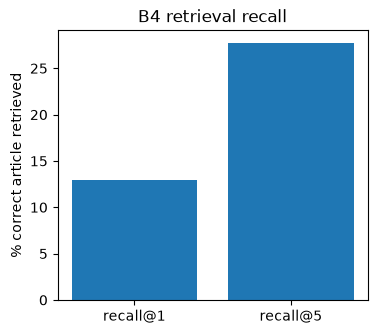

In [2]:
def norm(u):
    if not u:
        return u
    u = re.sub(r'^https?://', '', u.strip().lower())
    return u.replace('en.m.wikipedia.org', 'en.wikipedia.org').rstrip('/')

gt = {x['unique_id']: norm(x.get('wikipedia_url'))
      for x in json.load(open(BASE + '/encyclopedic_test_subset.json'))}

r1 = r5 = 0
for p in preds:
    rc = p.get('retrieved_context') or {}
    cands = [norm(c['wiki_url']) for c in rc.get('candidates', [])]
    g = gt.get(p['unique_id'])
    if cands and cands[0] == g:
        r1 += 1
    if g in cands:
        r5 += 1
n = len(preds)
print('recall@1: %.1f%%   recall@5: %.1f%%' % (100 * r1 / n, 100 * r5 / n))

plt.figure(figsize=(4, 3.5))
plt.bar(['recall@1', 'recall@5'], [100 * r1 / n, 100 * r5 / n])
plt.ylabel('% correct article retrieved'); plt.title('B4 retrieval recall')
plt.show()

## Where is the bottleneck? Answer accuracy on retrieval hit vs miss
Split by whether the correct article is in the top-5 candidates. Correctness is an exact-match proxy (a floor of BEM); the hit-vs-miss gap is the signal — a large gap means retrieval, not generation, is the bottleneck.

accuracy | HIT : 0.253 (n=277)
accuracy | MISS: 0.035 (n=723)


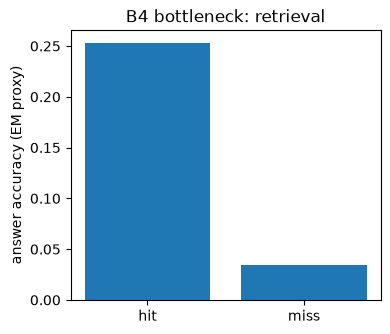

In [3]:
import string
PUNCT = set(string.punctuation + '\u2018\u2019\u00b4`_')
def _pre(a):
    a = a.lower().replace('\n', ' ').replace('\t', ' ').strip()
    a = ''.join('' if c in PUNCT else c for c in a)
    a = re.sub(r'\b(the answer is|a|an|the)\b', ' ', a)
    return ' '.join(a.split())
def correct(rec):
    if rec.get('prediction') is None:
        return False
    ref = str(rec['answer'])
    if rec['question_type'] == 'multi_answer':
        R = [x for x in (_pre(a) for a in ref.split('|')[0].split('&&')) if x]
        C = [x for x in (_pre(a) for a in rec['prediction'].replace(' and ', ',').replace(' & ', ',').split(',')) if x]
        u = len(set(R) | set(C)); return len(set(R) & set(C)) / u >= 0.5 if u else False
    return _pre(ref) == _pre(rec['prediction'])
def cands(p):
    rc = p.get('retrieved_context') or {}
    cs = [c['wiki_url'] for c in rc.get('candidates', [])] or ([rc['wiki_url']] if rc.get('wiki_url') else [])
    return [norm(u) for u in cs]
hit = [p for p in preds if gt.get(p['unique_id']) in cands(p)]
miss = [p for p in preds if gt.get(p['unique_id']) not in cands(p)]
acc = lambda s: sum(correct(p) for p in s) / len(s) if s else 0
print('accuracy | HIT : %.3f (n=%d)' % (acc(hit), len(hit)))
print('accuracy | MISS: %.3f (n=%d)' % (acc(miss), len(miss)))
plt.figure(figsize=(4, 3.5)); plt.bar(['hit', 'miss'], [acc(hit), acc(miss)])
plt.ylabel('answer accuracy (EM proxy)'); plt.title('B4 bottleneck: retrieval'); plt.show()

In [ ]:
# Qualitative: the reranked paragraphs fed to Qwen
for p in preds[:4]:
    rc = p.get('retrieved_context') or {}
    print('Q :', p['question'])
    print('GT:', str(p['answer'])[:70])
    print('Pred:', str(p['prediction'])[:110])
    print('-' * 60)

## Pros / cons / limitations

**Pros**
- Best baseline result (0.360), improves every question type over A.
- Decouples recall (top-k) from prompt size (top-3 paragraphs): raise k without bloating the prompt.
- Cross-encoder handles full paragraphs (512 tokens) and question↔passage interaction — fixes B3's failure.

**Cons**
- Extra model at query time (~1.1 GB, one forward per candidate paragraph).

**Limitations / headroom**
- recall@5 is still only ~28% → image retrieval is the ceiling. Accuracy (0.360) already exceeds it because the VLM answers some questions from the image alone.
- Levers left: larger top-k, a stronger/fine-tuned image retriever, a text-side retriever (Contriever) — and ultimately the agentic setting (C).